# Статистический анализ данных онлайн-сервиса книг

Во время изучения данных, подготовленных для расчёта LTV, была выдвинута гипотеза о том, что пользователи, которые приносят больший LTV, являются более лояльными, а значит, проводят в среднем больше времени за чтением и прослушиванием книг в приложении. При расчётах среднего LTV по городам было определено, что эта метрика в Санкт-Петербурге выше, чем в Москве.

Гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении по сравнению с пользователями из Москвы.

H0: среднее время активности пользователей в Москве и Санкт-Петербурге одинаково.

H1: cреднее время активности пользователей в Москве и Санкт-Петербурге различается.

Уровень значимости: 0.05

In [24]:
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

## Описание данных

**Поля таблицы bookmate_data:**
* city — город пользователя;
* puid — идентификатор пользователя;
* hours — общее количество часов активности

In [19]:
data = pd.read_csv('bookmate_data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


Перед проверкой гипотез исследуем данные на дубликаты, сравним размеры групп и показатель метрики.

## Проверка на дубликаты

In [20]:
# Проверка на дубликаты
sum(data['puid'].duplicated())

244

In [21]:
# Удаление дубликатов
data = data.drop_duplicates(subset=['puid'])
sum(data['puid'].duplicated())

0

## Сравнение размера групп и метрики

In [23]:
data['hours'].describe()

count    8540.000000
mean       10.984603
std        37.677623
min         0.000018
25%         0.059927
50%         0.909128
75%         5.970493
max       978.764775
Name: hours, dtype: float64

In [22]:
moscow_users = data[data['city'] == 'Москва'].dropna()
moscow_hours = moscow_users['hours'].mean()

spb_users = data[data['city'] == 'Санкт-Петербург'].dropna()
spb_hours = spb_users['hours'].mean()
print(f"Количество пользователей из Москвы = {moscow_users.shape[0]} и среднее количество часов = {moscow_hours}")
print(f"Количество пользователей из Санкт-Петербурга = {spb_users.shape[0]} и среднее количество часов = {spb_hours}")

Количество пользователей из Москвы = 6234 и среднее количество часов = 10.88109206345796
Количество пользователей из Санкт-Петербурга = 2306 и среднее количество часов = 11.264433367029522


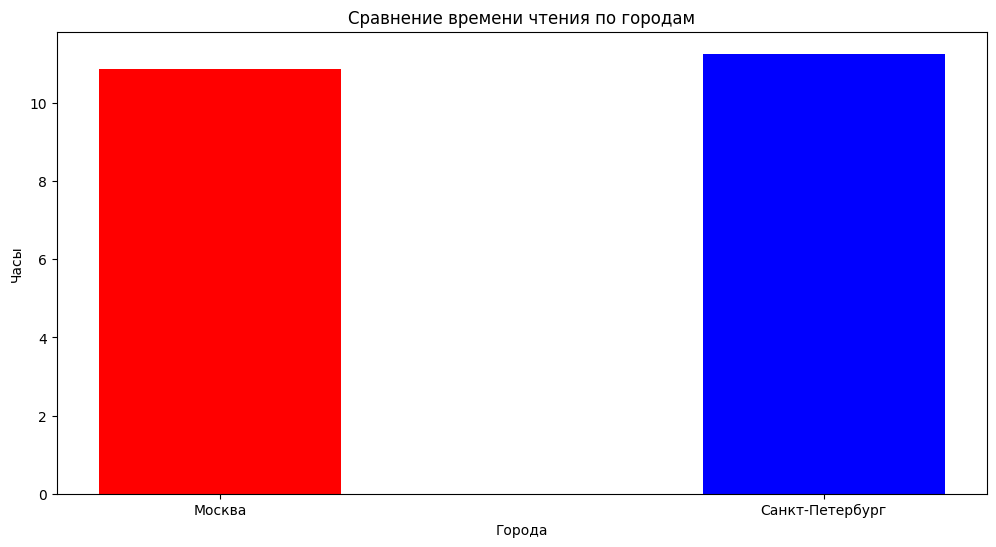

In [54]:
plt.figure(figsize=(12,6))
plt.bar(['Москва', 'Санкт-Петербург'], [moscow_hours, spb_hours], width=0.4, color=['red', 'blue'])
plt.xlabel('Города')
plt.ylabel('Часы')
plt.title('Сравнение времени чтения по городам')
plt.show()

**Наблюдение:**

количество пользователей из Санкт-Петербурга в 2,7 раза меньше, чем пользователей из Москвы. Однако среднее время, проведённое в приложении, у жителей Санкт-Петербурга на 0,38 часа больше. Стоит проверить это с помощью статистического теста.

## Выбросы

Проверим, есть ли выбросы в выборке. И, если есть, то как они повлияют на результат теста.

<Figure size 1400x600 with 0 Axes>

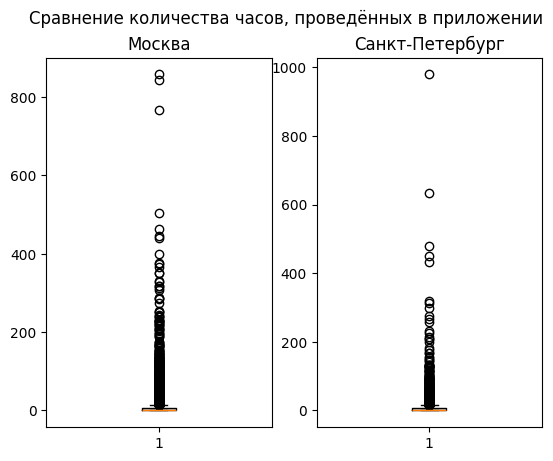

In [30]:
plt.figure(figsize=(14, 6))
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.boxplot(moscow_users['hours'])
ax1.set_title('Москва')

ax2.boxplot(spb_users['hours'])
ax2.set_title('Санкт-Петербург')

fig.suptitle('Сравнение количества часов, проведённых в приложении')
plt.show()

**Наблюдение:**

В обеих группах есть экстремальные значения, которые могут являться потенциальными выбросами.

In [33]:
Q1 = data['hours'].quantile(0.25)
Q3 = data['hours'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = data[data['hours'] > upper_bound]
print(f'Верхняя граница: {upper_bound:.2f}')
print(f'Количество выбросов: {len(outliers)}')
print(f'Доля выбросов: {len(outliers) / len(data):.2%}')

data_clean = data[data['hours'] <= upper_bound]
spb_users_clean = data_clean[data_clean['city'] == 'Санкт-Петербург']
moscow_users_clean = data_clean[data_clean['city'] == 'Москва']

Верхняя граница: 14.84
Количество выбросов: 1249
Доля выбросов: 14.63%


## Статистический тест

В качестве статистического теста был выбран тест Уэлча, так как он не учитывает разные дисперсии.

In [36]:
# Проверка гипотезы на исходной выборке
stats, pvalue = ttest_ind(
    spb_users['hours'],
    moscow_users['hours'],
    equal_var=False
)
print(f"По результатам статистического теста pvalue = {pvalue}")
alpha = 0.05
if pvalue > alpha:
    print("Нулевая гипотеза принимается. Среднее время активности в Санкт-Петербурге и Москве одинаково.")
else:
    print("Нулевая гипотеза отвергается. Среднее время активности в Санкт-Петербурге и Москве различается.")

По результатам статистического теста pvalue = 0.6871416237532628
Нулевая гипотеза принимается. Среднее время активности в Санкт-Петербурге и Москве одинаково.


In [35]:
# Проверка гипотезы на выборке без выбросов
stats, pvalue = ttest_ind(
    spb_users_clean['hours'],
    moscow_users_clean['hours'],
    equal_var=False
)
print(f"По результатам статистического теста pvalue = {pvalue}")
alpha = 0.05
if pvalue > alpha:
    print("Нулевая гипотеза принимается. Среднее время активности в Санкт-Петербурге и Москве одинаково.")
else:
    print("Нулевая гипотеза отвергается. Среднее время активности в Санкт-Петербурге и Москве различается.")

По результатам статистического теста pvalue = 0.35167631247650755
Нулевая гипотеза принимается. Среднее время активности в Санкт-Петербурге и Москве одинаково.


## Вывод

Несмотря на более высокий средний LTV пользователей Санкт-Петербурга, статистически значимых различий во времени активности между пользователями двух городов не обнаружено. Следовательно, повышенный LTV Санкт-Петербурга нельзя объяснить большей вовлечённостью пользователей по данной метрике.

Чем может быть вызван высокий LTV:
* более высокий retention (пользователи в среднем дольше остаются платящими клиентами)
* выше конверсия в платную подписку
* количество продлений подписки больше

Для анализа этих показателей потребуются дополнительные данные о покупках и продлениях подписки, даты регистрации пользователей.